# Ephys Data Analysis: From MATLAB .mat to PSTH

This notebook loads legacy MATLAB ephys/behavior data, explores the structure, extracts spike and event times, and visualizes peri-event activity (PSTH, raster) for flexible event/cluster selection.

In [137]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import numbers

## 1. Load and Convert MATLAB Data

In [138]:
# Load .mat file (update path as needed)
mat_path = 'BG_012_30102023_prot4_lickEndsTrial_data.mat'
data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)

def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

data_dict = mat_struct_to_dict(data)

## 2. Explore Data Structure

In [139]:
# Diagnostic: Print the structure and keys of data_dict to find the correct top-level key
print("type(data_dict):", type(data_dict))
if isinstance(data_dict, dict):
    print("data_dict keys:", data_dict.keys())
    # If only one key, print its type and keys/dtype.names
    main_key = list(data_dict.keys())[0]
    print(f"data_dict['{main_key}'] type:", type(data_dict[main_key]))
    if isinstance(data_dict[main_key], dict):
        print(f"data_dict['{main_key}'] keys:", data_dict[main_key].keys())
    elif hasattr(data_dict[main_key], 'dtype') and data_dict[main_key].dtype.names:
        print(f"data_dict['{main_key}'] dtype.names:", data_dict[main_key].dtype.names)
    else:
        print(f"data_dict['{main_key}']:", data_dict[main_key])
elif isinstance(data_dict, (list, np.ndarray)):
    print("data_dict[0] type:", type(data_dict[0]))
    if isinstance(data_dict[0], dict):
        print("data_dict[0] keys:", data_dict[0].keys())
    elif hasattr(data_dict[0], 'dtype') and data_dict[0].dtype.names:
        print("data_dict[0] dtype.names:", data_dict[0].dtype.names)
    else:
        print("data_dict[0]:", data_dict[0])
else:
    print("data_dict:", data_dict)

type(data_dict): <class 'dict'>
data_dict keys: dict_keys(['__header__', '__version__', '__globals__', 'data'])
data_dict['__header__'] type: <class 'bytes'>
data_dict['__header__']: b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu May 22 23:46:07 2025'


In [141]:
# Drill down to main experiment fields using the now-known structure
# data_dict['data'] -> .BG_012 -> .BG_012_30102023_prot4_lickEndsTrial -> NPX_probes, NI_events, behav_data

def get_main_exp_data(data_dict):
    # Step 1: Get the top-level struct
    struct = data_dict['data']
    # Step 2: Drill down to .BG_012
    if hasattr(struct, 'BG_012'):
        bg012_struct = struct.BG_012
    elif isinstance(struct, dict) and 'BG_012' in struct:
        bg012_struct = struct['BG_012']
    else:
        raise KeyError('BG_012 not found in struct')
    # Step 3: Drill down to .BG_012_30102023_prot4_lickEndsTrial
    if hasattr(bg012_struct, 'BG_012_30102023_prot4_lickEndsTrial'):
        prot4_struct = bg012_struct.BG_012_30102023_prot4_lickEndsTrial
    elif isinstance(bg012_struct, dict) and 'BG_012_30102023_prot4_lickEndsTrial' in bg012_struct:
        prot4_struct = bg012_struct['BG_012_30102023_prot4_lickEndsTrial']
    else:
        raise KeyError('BG_012_30102023_prot4_lickEndsTrial not found in BG_012_struct')
    # Print available fields at this level
    if hasattr(prot4_struct, '_fieldnames'):
        print('Main experiment fields:', prot4_struct._fieldnames)
    elif isinstance(prot4_struct, dict):
        print('Main experiment fields:', list(prot4_struct.keys()))
    else:
        print('Main experiment fields: not available (type: {})'.format(type(prot4_struct)))
    return prot4_struct

exp_data = get_main_exp_data(data_dict)
# Print summary of extracted objects
print('npx:', type(npx))
print('ni:', type(ni))
print('behav:', type(behav))

Main experiment fields: ['NPX_probes', 'NI_events', 'behav_data']
npx: <class 'scipy.io.matlab._mio5_params.mat_struct'>
ni: <class 'scipy.io.matlab._mio5_params.mat_struct'>
behav: <class 'scipy.io.matlab._mio5_params.mat_struct'>


## 3. Extract Ephys and Event Data

In [143]:
# Extract ephys and event data robustly, handling both dict and mat_struct cases

def get_field(obj, field):
    if isinstance(obj, dict):
        return obj[field]
    elif hasattr(obj, field):
        return getattr(obj, field)
    else:
        raise KeyError(f"Field '{field}' not found in object of type {type(obj)}")

# Get NPX_probes and NI_events
npx_arr = get_field(exp_data, 'NPX_probes')
ni_arr = get_field(exp_data, 'NI_events')
behav = get_field(exp_data, 'behav_data') if (hasattr(exp_data, 'behav_data') or (isinstance(exp_data, dict) and 'behav_data' in exp_data)) else None

# If these are arrays, get the first element (common for MATLAB cell arrays)
npx = npx_arr[0][0] if isinstance(npx_arr, np.ndarray) and npx_arr.ndim == 2 else npx_arr[0] if isinstance(npx_arr, (list, np.ndarray)) else npx_arr
ni = ni_arr[0][0] if isinstance(ni_arr, np.ndarray) and ni_arr.ndim == 2 else ni_arr[0] if isinstance(ni_arr, (list, np.ndarray)) else ni_arr

# Now extract spike and cluster info
spike_times = get_field(npx, 'st').flatten()  # spike times (seconds)
cluster_ids = get_field(npx, 'clu').flatten()
good_clusters = get_field(npx, 'cluster_id_KS_good').flatten()

# Use sample_rate if needed (should not divide if already in seconds)
sample_rate_val = get_field(npx, 'sample_rate') if (hasattr(npx, 'sample_rate') or (isinstance(npx, dict) and 'sample_rate' in npx)) else 30000
if hasattr(sample_rate_val, 'item'):
    sample_rate = sample_rate_val.item()
else:
    sample_rate = sample_rate_val
spike_times_sec = spike_times  # Already in seconds

print('npx:', type(npx))
print('ni:', type(ni))
print('behav:', type(behav))
print('spike_times shape:', spike_times.shape)
print('cluster_ids shape:', cluster_ids.shape)
print('good_clusters shape:', good_clusters.shape)

npx: <class 'scipy.io.matlab._mio5_params.mat_struct'>
ni: <class 'scipy.io.matlab._mio5_params.mat_struct'>
behav: <class 'scipy.io.matlab._mio5_params.mat_struct'>
spike_times shape: (19903845,)
cluster_ids shape: (19903845,)
good_clusters shape: (215,)


## 4. Robust Event Extraction (Flexible Field/Subfield)

In [145]:
# Select event and subfield for alignment
# Example: event_field = 'Baseline_ON', event_subfield = 'rise_t'
event_field = 'Baseline_ON'
event_subfield = 'rise_t'

event_arr = getattr(ni, event_field)
if event_subfield and isinstance(event_arr, np.ndarray) and event_arr.size == 1 and hasattr(event_arr[0], 'dtype') and event_subfield in event_arr[0].dtype.names:
    subfield_arr = event_arr[0][event_subfield]
    if isinstance(subfield_arr, np.ndarray) and subfield_arr.size == 1 and isinstance(subfield_arr[0], np.ndarray):
        event_times = np.array(subfield_arr[0]).flatten()
    else:
        event_times = np.array(subfield_arr).flatten()
elif isinstance(event_arr, np.ndarray) and event_arr.size == 1 and isinstance(event_arr[0], np.ndarray):
    event_times = np.array(event_arr[0]).flatten()
else:
    event_times = np.array(event_arr).flatten()

def to_numeric_array(arr):
    arr = np.array(arr).flatten()
    arr = [x for x in arr if isinstance(x, numbers.Number) and not isinstance(x, bool)]
    return np.array(arr, dtype=float)
event_times = to_numeric_array(event_times)
event_times_sec = event_times  # Already in seconds
print(f'Extracted {len(event_times_sec)} event times for {event_field}::{event_subfield or "<none>"}')
print('First 10 event times (s):', event_times_sec[:10])

Extracted 0 event times for Baseline_ON::rise_t
First 10 event times (s): []


## 5. Diagnostic: Check Event and Spike Time Ranges

In [146]:
print('spike_times_sec (min, max):', np.min(spike_times_sec), np.max(spike_times_sec))
print('event_times_sec (min, max):', np.min(event_times_sec), np.max(event_times_sec))

spike_times_sec (min, max): 0.0030666666666666668 12882.977833333332


ValueError: zero-size array to reduction operation minimum which has no identity

## 6. Raster and PSTH Visualization

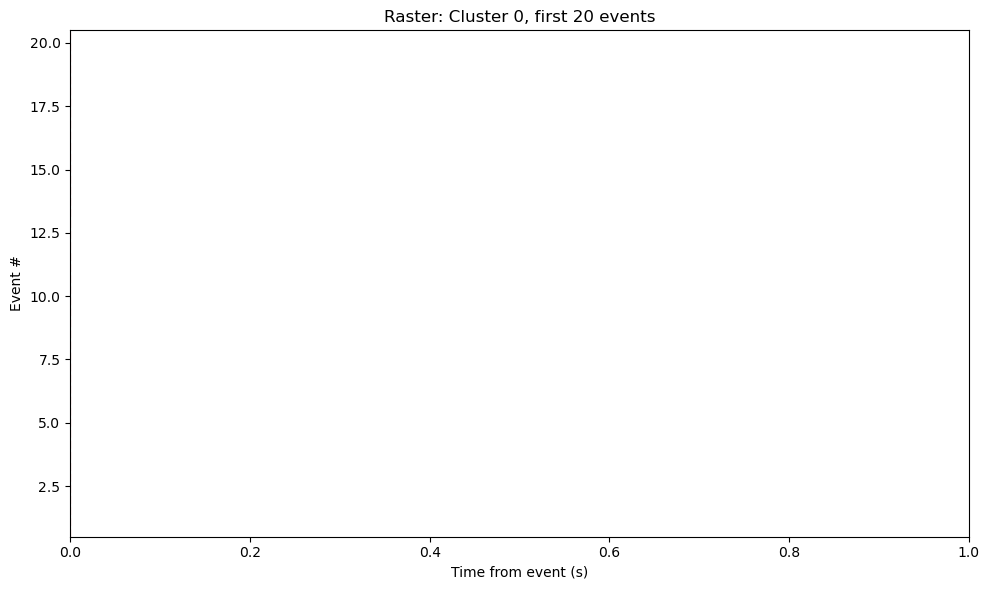

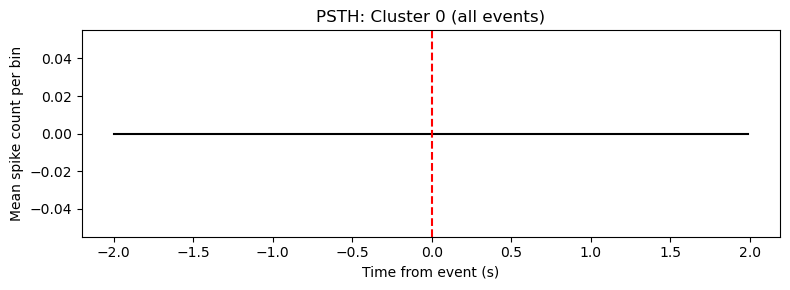

In [147]:
# Raster and PSTH for a selected cluster
cluster_idx = 0  # Change to inspect other clusters
clu = good_clusters[cluster_idx]
spike_times_clu = spike_times_sec[cluster_ids == clu]

n_events_to_plot = 20
window = [-2.0, 2.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)
events_to_plot = event_times_sec[:n_events_to_plot]

# Raster plot
plt.figure(figsize=(10, 6))
for i, t in enumerate(events_to_plot):
    aligned = spike_times_clu - t
    spikes_in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
    plt.scatter(spikes_in_window, np.full_like(spikes_in_window, i + 1), marker='|', color='k', s=30)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Event #')
plt.title(f'Raster: Cluster {clu}, first {n_events_to_plot} events')
plt.ylim(0.5, n_events_to_plot + 0.5)
plt.tight_layout()
plt.show()

# PSTH for this cluster, all events
all_counts = []
for t in event_times_sec:
    aligned = spike_times_clu - t
    counts, _ = np.histogram(aligned, bins=bins)
    all_counts.append(counts)
psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)

plt.figure(figsize=(8, 3))
plt.step(bins[:-1], psth, where='post', color='k')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Mean spike count per bin')
plt.title(f'PSTH: Cluster {clu} (all events)')
plt.tight_layout()
plt.show()

## 7. Multi-Cluster PSTH Screening

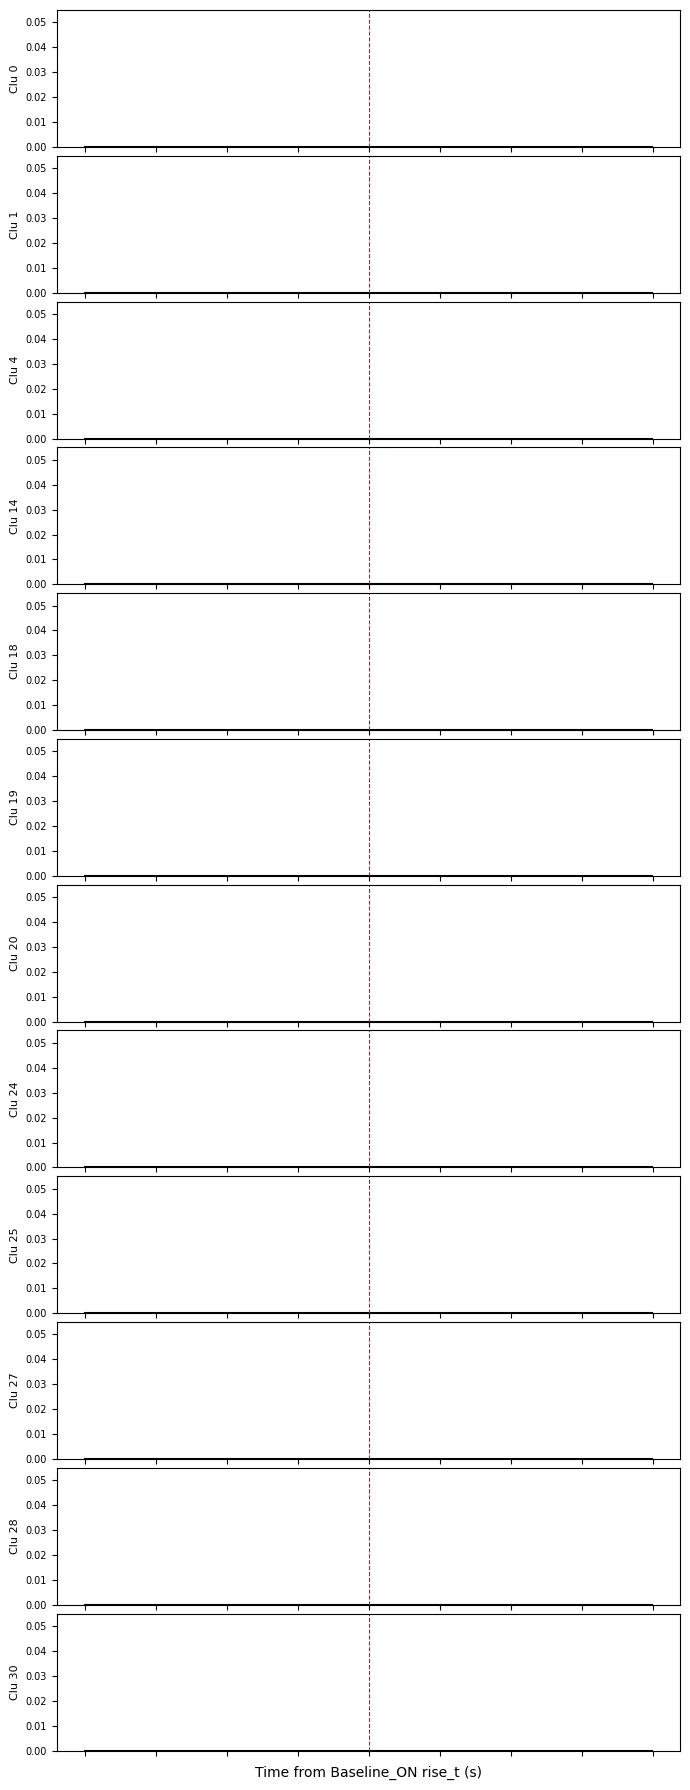

In [148]:
# Multi-cluster PSTH
n_plot = min(12, len(good_clusters))
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:12]
window = [-2.0, 2.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)

fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel(f'Time from {event_field} {event_subfield or ""} (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

In [149]:
# Diagnostic: Print the type and contents of 'struct' after extracting from data_dict['data']
struct = data_dict['data']
print('type(struct):', type(struct))
if isinstance(struct, (list, np.ndarray)):
    print('struct[0] type:', type(struct[0]))
    print('struct[0]:', struct[0])
    if hasattr(struct[0], 'dtype') and getattr(struct[0], 'dtype') is not None and hasattr(struct[0].dtype, 'names'):
        print('struct[0] dtype.names:', struct[0].dtype.names)
else:
    print('struct:', struct)
    if hasattr(struct, 'dtype') and getattr(struct, 'dtype') is not None and hasattr(struct.dtype, 'names'):
        print('struct dtype.names:', struct.dtype.names)

type(struct): <class 'scipy.io.matlab._mio5_params.mat_struct'>
struct: <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D28AAA70>


In [150]:
# Diagnostic: Print attributes and fields of the mat_struct object
def print_mat_struct_fields(struct):
    print('type:', type(struct))
    print('dir:', dir(struct))
    if hasattr(struct, '__dict__'):
        print('struct.__dict__:', struct.__dict__)
    if hasattr(struct, '_fieldnames'):
        print('struct._fieldnames:', struct._fieldnames)
        for field in struct._fieldnames:
            print(f"Field '{field}':", getattr(struct, field))

print_mat_struct_fields(struct)

type: <class 'scipy.io.matlab._mio5_params.mat_struct'>
dir: ['BG_012', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_fieldnames']
struct.__dict__: {'_fieldnames': ['BG_012'], 'BG_012': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D3FE18A0>}
struct._fieldnames: ['BG_012']
Field 'BG_012': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D3FE18A0>


In [151]:
# Drill down to the next level using the 'BG_012' field
bg012_struct = struct.BG_012
print('type(bg012_struct):', type(bg012_struct))
if hasattr(bg012_struct, '_fieldnames'):
    print('bg012_struct._fieldnames:', bg012_struct._fieldnames)
    for field in bg012_struct._fieldnames:
        print(f"Field '{field}':", getattr(bg012_struct, field))
else:
    print('bg012_struct:', bg012_struct)

type(bg012_struct): <class 'scipy.io.matlab._mio5_params.mat_struct'>
bg012_struct._fieldnames: ['BG_012_30102023_prot4_lickEndsTrial']
Field 'BG_012_30102023_prot4_lickEndsTrial': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D014E320>


In [ ]:
# Drill down to the next level using the 'BG_012_30102023_prot4_lickEndsTrial' field
prot4_struct = bg012_struct.BG_012_30102023_prot4_lickEndsTrial
print('type(prot4_struct):', type(prot4_struct))
if hasattr(prot4_struct, '_fieldnames'):
    print('prot4_struct._fieldnames:', prot4_struct._fieldnames)
    for field in prot4_struct._fieldnames:
        field_val = getattr(prot4_struct, field)
        print(f"Field '{field}': type={type(field_val)}; shape={getattr(field_val, 'shape', None)}; keys={list(field_val.keys()) if isinstance(field_val, dict) else ''}")
else:
    print('prot4_struct:', prot4_struct)

# Optionally, print a preview of the first few items for each field if it's an array or list
    
for field in getattr(prot4_struct, '_fieldnames', []):
    field_val = getattr(prot4_struct, field)
    if isinstance(field_val, (list, np.ndarray)) and len(field_val) > 0:
        print(f"Field '{field}' first item: {field_val[0]}")
    elif isinstance(field_val, dict):
        print(f"Field '{field}' keys: {list(field_val.keys())}")
    else:
        print(f"Field '{field}' value: {field_val}")

type(prot4_struct): <class 'scipy.io.matlab._mio5_params.mat_struct'>
prot4_struct._fieldnames: ['NPX_probes', 'NI_events', 'behav_data']
Field 'NPX_probes': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D955CB20>
Field 'NI_events': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D29DC940>
Field 'behav_data': <scipy.io.matlab._mio5_params.mat_struct object at 0x000001D9D955D480>
